In [468]:
# import
import polars as pl
import pyarrow as pa
import statsmodels.api as sm
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
import matplotlib.transforms as mtrans
from matplotlib.ticker import MaxNLocator
import matplotlib.ticker as mtick
from matplotlib import cm
from matplotlib.patches import Patch
# for using Times New Roman
import matplotlib.font_manager
import os as os
import subprocess
import sys as sys
import re
import threading
import logging
import time
import math
import warnings
warnings.filterwarnings('ignore')

In [469]:
# Using seaborn's style
plt.style.use(['ggplot', 'seaborn-v0_8-whitegrid'])

WIDTH = 345

def set_size(width, fraction=1):
    """ Set aesthetic figure dimensions to avoid scaling in latex.

    Parameters
    ----------
    width: float
            Width in pts
    fraction: float
            Fraction of the width which you wish the figure to occupy

    Returns
    -------
    fig_dim: tuple
            Dimensions of figure in inches
    """
    # Width of figure
    fig_width_pt = width * fraction

    # Convert from pt to inches
    inches_per_pt = 1 / 72.27

    # Golden ratio to set aesthetic figure height
    golden_ratio = (5**.5 - 1) / 2

    # Figure width in inches
    fig_width_in = fig_width_pt * inches_per_pt
    # Figure height in inches
    fig_height_in = fig_width_in * golden_ratio

    fig_dim = (fig_width_in, fig_height_in)

    return fig_dim

config = {
    "figure.figsize": set_size(WIDTH),
    "grid.linestyle": '--',
#     "hatch.color": '#eeeeee',
    "hatch.color": 'grey',
    "hatch.linewidth": 0.618,
    # Use LaTeX to write all text
    "text.usetex": False,
    "font.family": "Times New Roman",
    #"text.latex.unicode": True,
    "axes.unicode_minus": True,
    # Use 10pt font in plots, to match 10pt font in document
    "axes.labelsize": 22,
    "font.size": 22,
    "legend.fontsize": 22,
    # Make the label fonts a little smaller
    "xtick.labelsize": 22,
    "ytick.labelsize": 22,
    "legend.handletextpad": 0.5,
    "legend.columnspacing": 0.9,
    "legend.numpoints": 3,
}

mpl.rcParams.update(config)

In [470]:
save_pdf_path = "/Users/liuyaodai/UC_Merced/paper/CCL_model/SC25/pre-cut"

In [471]:
import polars as pl
import re

def lyd_bench_parse_logGP(filename: str) -> pl.DataFrame:
    with open(filename, 'r') as file:
        file_contents = file.read()

    # More general regex: captures size, both (n, d, latency)
    regex = re.compile(
        r"=== Data Size: (?P<s>\d+) bytes ===\s*"
        r"Latency \(n=10, d=(?P<d10>\d+)\): (?P<lat10>[\d.]+) ms\s*"
        r"Latency \(n=1, d=(?P<d1>\d+)\): (?P<lat1>[\d.]+) ms",
        re.MULTILINE
    )

    matches = regex.findall(file_contents)

    rows = []
    for s, d10, lat10, d1, lat1 in matches:
        # optional: validate d10 == d1
        if d10 != d1:
            print(f"Warning: Delay mismatch for size {s} → d10={d10}, d1={d1}")
        rows.append({
            "s": int(s),
            "d": int(d10),  # use either d10 or d1
            "latency_n10_d(ms)": float(lat10),
            "latency_n1_d(ms)": float(lat1)
        })

    return pl.DataFrame(rows)

In [472]:
import polars as pl
import re

def netgauge_parse_logGP(filename: str) -> pl.DataFrame:
    with open(filename, 'r') as file:
        file_contents = file.read()

    # Updated regex to handle spacing and units
    regex = re.compile(
        r"L=(?P<L>[\d.]+)\s+us\s+"
        r"s=(?P<s>\d+)\s+"
        r"o_s=(?P<o_s>[\d.]+)\s+us\s+"
        r"o_r=(?P<o_r>[\d.]+)\s+us\s+"
        r"g=(?P<g>[\d.]+)\s+us\s+"
        r"G=(?P<G>[\d.]+)\s+"
        r"\((?P<GiBs>[\d.]+)\s+GiB/s\)\s+"
        r"lsqu\(g,G\)=(?P<lsqu>[\d.]+)\s+"
        r"PRTT_1_0=(?P<prtt>[\d.]+)\s+us",
        re.MULTILINE
    )

    matches = regex.findall(file_contents)

    rows = []
    for L, s, o_s, o_r, g, G, GiBs, lsqu, prtt in matches:
        rows.append({
            "L(us)": float(L),
            "s": int(s),
            "o_s(us)": float(o_s),
            "o_r(us)": float(o_r),
            "g(us)": float(g),
            "G(us/B)": float(G),
            "Bandwidth(GiB/s)": float(GiBs),
            "lsqu(g,G)": float(lsqu),
            "PRTT_1_0(us)": float(prtt)
        })

    return pl.DataFrame(rows)

## List LogGP model Parameters

In [473]:
import polars as pl

lyd_bench_filename_noext = "/Users/liuyaodai/UC_Merced/paper/CCL_model/SC25/lyd_benchmark_results/padsys/mpigauge_rdma.out"

# Parse the logGP results
df_lyd_bench_raw = lyd_bench_parse_logGP(filename=f"{lyd_bench_filename_noext}")

print(df_lyd_bench_raw)

netgauge_filename_noext = "/Users/liuyaodai/UC_Merced/paper/CCL_model/SC25/netgauge_results/padsys/netgauge_rdma.stdout"

df_netgauge = netgauge_parse_logGP(filename=f"{netgauge_filename_noext}")

df_netgauge = df_netgauge.with_columns([
    (pl.col("s") / (1024 * 1024)).alias("s(MB)"),
    ((1 / pl.col("G(us/B)")) * (1000**2 / 1024**3)).alias("1/G(GB/s)")
]).drop("Bandwidth(GiB/s)", "lsqu(g,G)", "PRTT_1_0(us)")

print(df_netgauge)



shape: (256, 4)
┌───────────┬───────┬───────────────────┬──────────────────┐
│ s         ┆ d     ┆ latency_n10_d(ms) ┆ latency_n1_d(ms) │
│ ---       ┆ ---   ┆ ---               ┆ ---              │
│ i64       ┆ i64   ┆ f64               ┆ f64              │
╞═══════════╪═══════╪═══════════════════╪══════════════════╡
│ 1048576   ┆ 0     ┆ 1.252             ┆ 0.228            │
│ 2097152   ┆ 0     ┆ 1.626             ┆ 0.295            │
│ 3145728   ┆ 0     ┆ 2.104             ┆ 0.375            │
│ 4194304   ┆ 0     ┆ 2.595             ┆ 0.454            │
│ 5242880   ┆ 0     ┆ 3.071             ┆ 0.554            │
│ …         ┆ …     ┆ …                 ┆ …                │
│ 130023424 ┆ 20000 ┆ 444.313           ┆ 80.627           │
│ 131072000 ┆ 20000 ┆ 444.338           ┆ 80.6             │
│ 132120576 ┆ 20000 ┆ 444.343           ┆ 80.616           │
│ 133169152 ┆ 20000 ┆ 444.298           ┆ 80.604           │
│ 134217728 ┆ 20000 ┆ 444.359           ┆ 80.614           │
└───────

In [474]:
df_os = df_lyd_bench_raw.filter(pl.col("d") == 20000).with_columns(
    (
        (pl.col("latency_n10_d(ms)") - pl.col("latency_n1_d(ms)")) / 9 - 40
    ).alias("o_s(ms)")
)

print(df_os)

import numpy as np
import polars as pl

# def rolling_linear_fit_G_g(df: pl.DataFrame, df_os: pl.DataFrame) -> pl.DataFrame:
#     # Step 1: Filter for d == 0 and compute y
#     df_d0 = df.filter(pl.col("d") == 0).with_columns(
#         ((pl.col("latency_n10_d(ms)") - pl.col("latency_n1_d(ms)")) / 9 - df_os.("o_s(ms)")).alias("y")
#     ).sort("s")

#     s_values = df_d0["s"].to_numpy()
#     y_values = df_d0["y"].to_numpy()

def rolling_linear_fit_G_g(df: pl.DataFrame, df_os: pl.DataFrame) -> pl.DataFrame:
    # Step 1: Join df with df_os to get o_s(ms) aligned by 's'
    df_os = df_os.select(pl.col("s"), pl.col("o_s(ms)"))
    df = df.join(df_os, on="s", how="left")

    # Step 2: Filter for d == 0 and compute y
    df_d0 = df.filter(pl.col("d") == 0).with_columns(
        (
            (pl.col("latency_n10_d(ms)") - pl.col("latency_n1_d(ms)")) / 9
        ).alias("y")
    ).sort("s")

    results = []

    s_values = df_d0["s"].to_numpy()
    y_values = df_d0["y"].to_numpy()
    
    # Step 2: Start from the second value (index 1)
    for i in range(1, len(s_values)):
        x = s_values[:i+1]
        y = y_values[:i+1]

        # Linear least squares: y = G*x + g
        X = np.vstack([x, np.ones_like(x)]).T
        G_i, g_i = np.linalg.lstsq(X, y, rcond=None)[0]

        results.append({"s": s_values[i], "Estimated_G(ms/B)": G_i, "Estimated_g(ms)": g_i})

    return pl.DataFrame(results)

df_rolling_fit = rolling_linear_fit_G_g(df_lyd_bench_raw, df_os)

print(df_rolling_fit)

# Join on the 's' column
df_lyd_bench = df_os.join(df_rolling_fit, on="s", how="inner")

# Select and rename columns as needed
df_lyd_bench = df_lyd_bench.select([
    pl.col("s"),
    (pl.col("s")/1024**2).alias("s(MB)"),
    (pl.col("o_s(ms)")*1000).alias("o_s(us)"),
    (pl.col("Estimated_g(ms)")*1000).alias("g(us)"),
    (pl.col("Estimated_G(ms/B)")*1000).alias("G(us/B)"),
    ((1/pl.col("Estimated_G(ms/B)"))*(1000/1024**3)).alias("1/G(GB/s)")
])

print(df_lyd_bench)

shape: (128, 5)
┌───────────┬───────┬───────────────────┬──────────────────┬──────────┐
│ s         ┆ d     ┆ latency_n10_d(ms) ┆ latency_n1_d(ms) ┆ o_s(ms)  │
│ ---       ┆ ---   ┆ ---               ┆ ---              ┆ ---      │
│ i64       ┆ i64   ┆ f64               ┆ f64              ┆ f64      │
╞═══════════╪═══════╪═══════════════════╪══════════════════╪══════════╡
│ 1048576   ┆ 20000 ┆ 441.666           ┆ 80.312           ┆ 0.150444 │
│ 2097152   ┆ 20000 ┆ 441.686           ┆ 80.309           ┆ 0.153    │
│ 3145728   ┆ 20000 ┆ 441.714           ┆ 80.314           ┆ 0.155556 │
│ 4194304   ┆ 20000 ┆ 441.739           ┆ 80.311           ┆ 0.158667 │
│ 5242880   ┆ 20000 ┆ 441.763           ┆ 80.318           ┆ 0.160556 │
│ …         ┆ …     ┆ …                 ┆ …                ┆ …        │
│ 130023424 ┆ 20000 ┆ 444.313           ┆ 80.627           ┆ 0.409556 │
│ 131072000 ┆ 20000 ┆ 444.338           ┆ 80.6             ┆ 0.415333 │
│ 132120576 ┆ 20000 ┆ 444.343           ┆ 80.616

### plot the o, g and a 

In [475]:
import matplotlib.pyplot as plt

def plot_latency_vs_size(
    df,
    x_col='s(MB)',
    y_cols=None,  # List of y columns to plot
    labels=None,
    markers=None,
    colors=None,
    y_ticks=None,
    x_ticks=(0, 64, 128),
    xlabel='Size (MB)',
    ylabel='Latency (us)',
    legend_loc='upper center',
    legend_ncol=None,
    legend_bbox=(0.5, 0.2),
    width_ratio=1,
    height_ratio=1,
    legend_columnspacing=0.8,
    ylabel_coords=(None, None),
    pdf_filename=None  # ✅ Optional filename to save the plot as PDF
):
    if y_cols is None:
        raise ValueError("Please provide y_cols (list of columns to plot).")

    df_pandas = df.to_pandas().sort_values(by=x_col)

    plt.rcParams['axes.edgecolor'] = 'black'
    dim = set_size(WIDTH, fraction=width_ratio)
    dim = (dim[0], dim[1] * height_ratio)  # ✅ scale height by ratio
    fig, axe = plt.subplots(figsize=dim, constrained_layout=True)

    default_markers = ['o', '^', 's', 'D', '*', 'x', '+']
    default_colors = plt.get_cmap('tab10').colors
    n = len(y_cols)

    labels = labels or y_cols
    markers = (markers or default_markers * ((n // len(default_markers)) + 1))[:n]
    colors = (colors or default_colors * ((n // len(default_colors)) + 1))[:n]

    for y, label, marker, color in zip(y_cols, labels, markers, colors):
        axe.plot(df_pandas[x_col], df_pandas[y], label=label, marker=marker, markersize=2, color=color)

    if any((df_pandas[y] < 0).any() for y in y_cols):
        axe.axhline(0, color='gray', linestyle='--', linewidth=1)

    axe.set_xlim(left=0)
    if x_ticks:
        axe.set_xticks(x_ticks)
    if y_ticks:
        axe.set_yticks(y_ticks)
    axe.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

    axe.set_xlabel(xlabel)
    if ylabel_coords == (None, None):
        axe.set_ylabel(ylabel)
    else:
        axe.text(
            ylabel_coords[0], ylabel_coords[1], ylabel,
            va='center', rotation='vertical', transform=axe.transAxes,
            fontsize=plt.rcParams['axes.labelsize']
        )
    axe.tick_params(axis='both')

    axe.legend(
        loc=legend_loc,
        bbox_to_anchor=legend_bbox,
        ncol=legend_ncol or min(n, 4),
        frameon=False,
        handletextpad=0.4,
        columnspacing=legend_columnspacing
    )
    # ✅ Save to PDF if filename is provided
    if pdf_filename:
        full_path = os.path.join(save_pdf_path, pdf_filename)
        plt.savefig(full_path, format='pdf', bbox_inches='tight')
        print(f"📄 Plot saved to: {full_path}")

    plt.show()

📄 Plot saved to: /Users/liuyaodai/UC_Merced/paper/CCL_model/SC25/pre-cut/lyd_bench_o_s_o_r.pdf


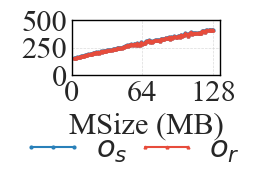

📄 Plot saved to: /Users/liuyaodai/UC_Merced/paper/CCL_model/SC25/pre-cut/lyd_bench_g.pdf


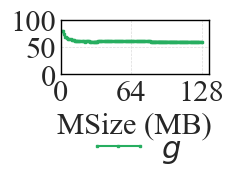

In [476]:
plot_latency_vs_size(
    df=df_lyd_bench,
    y_cols=['o_s(us)', 'o_s(us)'],
    labels=[r'$o_s$', r'$o_r$'],
    markers=['o', '^', '*', 's'],
    colors = ['#2980b9', '#e74c3c', '#27ae60', '#f39c12', '#8e44ad', '#16a085', '#d35400', '#2c3e50'],
    y_ticks=[0, 250, 500],
    legend_bbox=(0.4, -0.62),
    width_ratio=0.4,
    height_ratio=0.6,
    xlabel='MSize (MB)',
    ylabel='',
    legend_columnspacing=0.3,
    pdf_filename='lyd_bench_o_s_o_r.pdf' 
)

plot_latency_vs_size(
    df=df_lyd_bench,
    y_cols=['g(us)'],
    labels=[r'$g$'],
    markers=['s'],
    colors=['#27ae60'],
    y_ticks=[0, 50, 100],
    legend_bbox=(0.5, -0.62),
    width_ratio=0.4,
    height_ratio=0.6,
    xlabel='MSize (MB)',
    ylabel='',
    pdf_filename='lyd_bench_g.pdf' 
)

📄 Plot saved to: /Users/liuyaodai/UC_Merced/paper/CCL_model/SC25/pre-cut/Netgauge_o_s_o_r.pdf


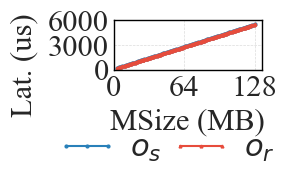

📄 Plot saved to: /Users/liuyaodai/UC_Merced/paper/CCL_model/SC25/pre-cut/Netgauge_g.pdf


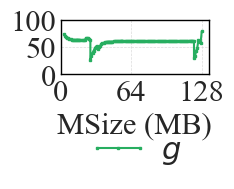

In [477]:
plot_latency_vs_size(
    df=df_netgauge,
    y_cols=['o_s(us)', 'o_r(us)'],
    labels=[r'$o_s$', r'$o_r$'],
    markers=['o', '^', '*', 's'],
    colors = ['#2980b9', '#e74c3c', '#27ae60', '#f39c12', '#8e44ad', '#16a085', '#d35400', '#2c3e50'],
    y_ticks=[0, 3000, 6000],
    legend_bbox=(0.35, -0.75),
    width_ratio=0.4,
    height_ratio=0.55,
    xlabel='MSize (MB)',
    ylabel='Lat. (us)',
    legend_ncol=2,
    legend_columnspacing=0.3,
    ylabel_coords=(-0.7, 0.1),
    pdf_filename='Netgauge_o_s_o_r.pdf' 
)

plot_latency_vs_size(
    df=df_netgauge,
    y_cols=['g(us)'],
    labels=[r'$g$'],
    markers=['s'],
    colors = ['#27ae60'], 
    y_ticks=[0, 50, 100],
    legend_bbox=(0.5, -0.65),
    width_ratio=0.4,
    height_ratio=0.6,
    xlabel='MSize (MB)',
    ylabel='',
    pdf_filename='Netgauge_g.pdf' 
)

In [478]:
import matplotlib.pyplot as plt

def plot_latency_two_sources(
    df1,
    df2,
    x_col='s(MB)',
    y_cols=None,  # List of y columns to plot
    df1_labels=None,
    df2_labels=None,
    df1_markers=None,
    df2_markers=None,
    df1_colors=None,
    df2_colors=None,
    y_ticks=None,
    x_ticks=(0, 64, 128),
    xlabel='Message Size (MB)',
    ylabel='BW (GB/s)',
    legend_loc='upper center',
    legend_ncol=None,
    legend_bbox=(0.5, 0.2),
    width_ratio=1,
    height_ratio=1,
    ylabel_coords=(None, None),
    pdf_filename=None  # ✅ Optional filename to save the plot as PDF
):
    if y_cols is None:
        raise ValueError("Please provide y_cols (list of columns to plot).")

    df1_pandas = df1.to_pandas().sort_values(by=x_col)
    df2_pandas = df2.to_pandas().sort_values(by=x_col)

    dim = set_size(WIDTH, fraction=width_ratio)
    dim = (dim[0], dim[1] * height_ratio)  # ✅ scale height by ratio
    fig, axe = plt.subplots(figsize=dim, constrained_layout=True)

    # Set up style defaults
    default_markers = ['o', '^', 's', 'D', '*', 'x', '+']
    default_colors = ['#2980b9', '#e74c3c', '#27ae60', '#f39c12', '#8e44ad', '#16a085', '#d35400', '#2c3e50']

    n = len(y_cols)
    df1_labels = df1_labels or [f'DF1 {col}' for col in y_cols]
    df2_labels = df2_labels or [f'DF2 {col}' for col in y_cols]

    df1_markers = (df1_markers or default_markers)[:n]
    df2_markers = (df2_markers or default_markers[::-1])[:n]

    df1_colors = (df1_colors or default_colors)[:n]
    df2_colors = (df2_colors or default_colors[n:] + default_colors[:n])[:n]

    # Plot df1
    for y, label, marker, color in zip(y_cols, df1_labels, df1_markers, df1_colors):
        axe.plot(df1_pandas[x_col], df1_pandas[y], label=label, marker=marker, markersize=2, color=color)

    # Plot df2
    for y, label, marker, color in zip(y_cols, df2_labels, df2_markers, df2_colors):
        axe.plot(df2_pandas[x_col], df2_pandas[y], label=label, marker=marker, markersize=2, color=color)

    # Optional: Add zero reference line
    if any((df1_pandas[y] < 0).any() or (df2_pandas[y] < 0).any() for y in y_cols):
        axe.axhline(0, color='gray', linestyle='--', linewidth=1)

    # Axes settings
    axe.set_xlim(left=0)
    if x_ticks:
        axe.set_xticks(x_ticks)
    if y_ticks:
        axe.set_yticks(y_ticks)
        # # Remove y-axis tick label at 0 (if it's there)
        # yticks = axe.get_yticks()
        # yticklabels = ["" if y == 0 else str(int(y)) for y in yticks]
        # axe.set_yticklabels(yticklabels)
    axe.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

    # Axis labels
    # Axis labels
    axe.set_xlabel(xlabel)
    if ylabel_coords == (None, None):
        axe.set_ylabel(ylabel)
    else:
        axe.text(
            ylabel_coords[0], ylabel_coords[1], ylabel,
            va='center', rotation='vertical', transform=axe.transAxes,
            fontsize=plt.rcParams['axes.labelsize']
        )
    axe.tick_params(axis='both')

    # Legend
    axe.legend(
        loc=legend_loc,
        bbox_to_anchor=legend_bbox,
        ncol=legend_ncol or min(2 * n, 4),
        frameon=False,
        handletextpad=-0.2,
        columnspacing=0,
        handlelength=1.2
    )

    # ✅ Save to PDF if filename is provided
    if pdf_filename:
        full_path = os.path.join(save_pdf_path, pdf_filename)
        plt.savefig(full_path, format='pdf', bbox_inches='tight')
        print(f"📄 Plot saved to: {full_path}")

    plt.show()

📄 Plot saved to: /Users/liuyaodai/UC_Merced/paper/CCL_model/SC25/pre-cut/lyd_bench_netgauge_1_G.pdf


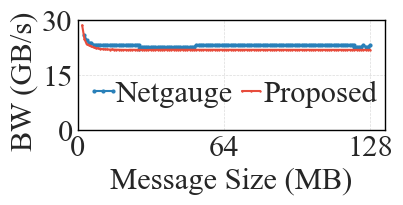

In [479]:
plot_latency_two_sources(
    df1=df_netgauge,
    df2=df_lyd_bench,
    y_cols=['1/G(GB/s)'],
    df1_labels=[r'Netgauge'],
    df2_labels=[r'Proposed'],
    y_ticks=[0, 15, 30],
    x_ticks=[0, 64, 128],
    width_ratio=0.82,
    height_ratio=0.8,
    legend_bbox=(0.5, 0.7),
    ylabel_coords=(-0.22, 0.45),
    pdf_filename='lyd_bench_netgauge_1_G.pdf'
)

In [480]:
import polars as pl
import re
import numpy as np

def lyd_bench_L_Latency_parse_logGP(filename: str) -> pl.DataFrame:
    with open(filename, 'r') as file:
        content = file.read()

    # Extract data size and latency (n=1, d=0)
    block_regex = re.compile(
        r"=== Data Size: (?P<s>\d+) bytes ===.*?"
        r"Latency \(n=10, d=0\): (?P<latency_1_0>[-\d.]+) ms",
        re.DOTALL
    )
    block_matches = block_regex.findall(content)

    # Assemble DataFrame
    rows = []
    for s, latency_1_0 in block_matches:
        rows.append({
            "s": int(s),
            "latency_10_0(ms)": float(latency_1_0)
        })

    df = pl.DataFrame(rows)

    # Extract all L values and get the minimum
    L_matches = re.findall(r"L:\s+([-+]?\d*\.\d+|\d+)\s*ms", content)
    L_values = [float(l) for l in L_matches]
    L = min(L_values) if L_values else None

    df = df.with_columns(pl.lit(L).alias("L(ms)"))

    return df

lyd_bench_filename_noext = "/Users/liuyaodai/UC_Merced/paper/CCL_model/SC25/lyd_benchmark_results/padsys/mpigauge_rdma.out"

# Parse the logGP results
df_lyd_bench_compare_time = lyd_bench_L_Latency_parse_logGP(filename=f"{lyd_bench_filename_noext}")

print(df_lyd_bench_compare_time)

shape: (128, 3)
┌───────────┬──────────────────┬───────┐
│ s         ┆ latency_10_0(ms) ┆ L(ms) │
│ ---       ┆ ---              ┆ ---   │
│ i64       ┆ f64              ┆ f64   │
╞═══════════╪══════════════════╪═══════╡
│ 1048576   ┆ 1.252            ┆ 0.001 │
│ 2097152   ┆ 1.626            ┆ 0.001 │
│ 3145728   ┆ 2.104            ┆ 0.001 │
│ 4194304   ┆ 2.595            ┆ 0.001 │
│ 5242880   ┆ 3.071            ┆ 0.001 │
│ …         ┆ …                ┆ …     │
│ 130023424 ┆ 61.267           ┆ 0.001 │
│ 131072000 ┆ 61.68            ┆ 0.001 │
│ 132120576 ┆ 62.239           ┆ 0.001 │
│ 133169152 ┆ 62.664           ┆ 0.001 │
│ 134217728 ┆ 63.211           ┆ 0.001 │
└───────────┴──────────────────┴───────┘


In [481]:
compare_df = df_lyd_bench_compare_time.join(df_lyd_bench.select(['s', 'o_s(us)', 'G(us/B)', 'g(us)']), on='s', how='left')

compare_df = compare_df.with_columns(
    (
        (2 * pl.col('L(ms)') * 1000 +
        4 * pl.col('o_s(us)') + 9 * pl.col('g(us)') +
        11 * (pl.col('s') - 1) * pl.col('G(us/B)'))/1000
    ).alias('pre_latency(Our)')
)

compare_df = compare_df.join(df_netgauge.select(['s', 'o_s(us)', 'G(us/B)', 'g(us)']), on='s', how='left', suffix='_netgauge')

compare_df = compare_df.filter(pl.col('s') > 2097152)

compare_df = compare_df.with_columns(
    (
        (2 * pl.col('L(ms)') * 1000 +
        4 * pl.col('o_s(us)_netgauge') + 9 * pl.col('g(us)') +
        11 * (pl.col('s') - 1) * pl.col('G(us/B)_netgauge'))/1000
    ).alias('pre_latency(Netgauge)')
).drop('o_s(us)', 'o_s(us)_netgauge', 'G(us/B)', 'G(us/B)_netgauge')

compare_df = compare_df.with_columns([
    (pl.col("s") / (1024*1024)).alias("s(MB)")
]).drop("s")

compare_df = compare_df.with_columns([
    (abs(pl.col("pre_latency(Our)") - pl.col("latency_10_0(ms)")) / pl.col("latency_10_0(ms)") * 100).alias("pred_error_our"),
    (abs(pl.col("pre_latency(Netgauge)") - pl.col("latency_10_0(ms)")) / pl.col("latency_10_0(ms)") * 100).alias("pred_error_Netgauge") 
])

print(compare_df)


shape: (128, 9)
┌─────────────┬───────┬───────────┬─────────────┬───┬────────────┬───────┬────────────┬────────────┐
│ latency_10_ ┆ L(ms) ┆ g(us)     ┆ pre_latency ┆ … ┆ pre_latenc ┆ s(MB) ┆ pred_error ┆ pred_error │
│ 0(ms)       ┆ ---   ┆ ---       ┆ (Our)       ┆   ┆ y(Netgauge ┆ ---   ┆ _our       ┆ _Netgauge  │
│ ---         ┆ f64   ┆ f64       ┆ ---         ┆   ┆ )          ┆ f64   ┆ ---        ┆ ---        │
│ f64         ┆       ┆           ┆ f64         ┆   ┆ ---        ┆       ┆ f64        ┆ f64        │
│             ┆       ┆           ┆             ┆   ┆ f64        ┆       ┆            ┆            │
╞═════════════╪═══════╪═══════════╪═════════════╪═══╪════════════╪═══════╪════════════╪════════════╡
│ 2.104       ┆ 0.001 ┆ 72.925926 ┆ 2.573055    ┆ … ┆ 2.658022   ┆ 3.0   ┆ 22.293495  ┆ 26.331851  │
│ 2.595       ┆ 0.001 ┆ 68.777778 ┆ 3.088511    ┆ … ┆ 3.298509   ┆ 4.0   ┆ 19.017752  ┆ 27.110157  │
│ 3.071       ┆ 0.001 ┆ 67.733333 ┆ 3.5736      ┆ … ┆ 3.955455   ┆ 5.0   ┆ 

In [482]:
import matplotlib.pyplot as plt

def plot_compare_latency_vs_size(
    df,
    x_col='s(MB)',
    y_cols=None,  # List of y columns to plot
    labels=None,
    markers=None,
    colors=None,
    y_ticks=None,
    x_ticks=(0, 64, 128),
    xlabel='Message Size (MB)',
    ylabel='Pred. Error (%)',
    legend_loc='upper center',
    legend_ncol=None,
    legend_bbox=(0.5, 0.2),
    width_ratio=1,
    height_ratio=1,
    pdf_filename=None  # ✅ Optional filename to save the plot as PDF
):
    # Default y_cols if not provided
    if y_cols is None:
        raise ValueError("Please provide y_cols (list of columns to plot).")

    df_pandas = df.to_pandas().sort_values(by=x_col)

    # Set figure size
    dim = set_size(WIDTH, fraction=width_ratio)
    dim = (dim[0], dim[1] * height_ratio)  # ✅ scale height by ratio
    fig, axe = plt.subplots(figsize=dim, constrained_layout=True)

    # Auto-generate labels, markers, colors if not enough provided
    default_markers = ['o', '^', 's', 'D', '*', 'x', '+']
    default_colors = plt.get_cmap('tab10').colors
    n = len(y_cols)

    labels = labels or y_cols
    markers = (markers or default_markers * ((n // len(default_markers)) + 1))[:n]
    colors = (colors or default_colors * ((n // len(default_colors)) + 1))[:n]

    # Plot each line
    for y, label, marker, color in zip(y_cols, labels, markers, colors):
        axe.plot(df_pandas[x_col], df_pandas[y], label=label, marker=marker, markersize=2, color=color)

    # Optional: Add zero reference line
    if any((df_pandas[y] < 0).any() for y in y_cols):
        axe.axhline(0, color='gray', linestyle='--', linewidth=1)

    # Axes settings
    axe.set_xlim(left=0)
    if x_ticks:
        axe.set_xticks(x_ticks)
    if y_ticks:
        axe.set_yticks(y_ticks)
    axe.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

    # Labels
    axe.set_xlabel(xlabel)
    axe.set_ylabel(ylabel)
    axe.yaxis.label.set_position((-0.1, 0.3))  # (x, y) in axes coordinates
    axe.tick_params(axis='both')

    # Legend
    axe.legend(
        loc=legend_loc,
        bbox_to_anchor=legend_bbox,
        ncol=legend_ncol or min(n, 4),
        frameon=False,
        handletextpad=0,
        columnspacing=0.3,
        handlelength=1.3
    )

    # ✅ Save to PDF if filename is provided
    if pdf_filename:
        full_path = os.path.join(save_pdf_path, pdf_filename)
        plt.savefig(full_path, format='pdf', bbox_inches='tight')
        print(f"📄 Plot saved to: {full_path}")

    plt.show()

📄 Plot saved to: /Users/liuyaodai/UC_Merced/paper/CCL_model/SC25/pre-cut/lyd_bench_netgauge_compare_latency.pdf


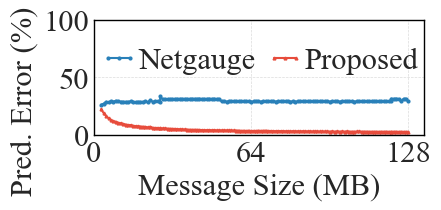

In [483]:
plot_compare_latency_vs_size(
    df=compare_df,
    y_cols=['pred_error_Netgauge','pred_error_our'],
    labels=[r'Netgauge',r'Proposed'],
    markers=['o', '^', '*'],
    colors = ['#2980b9', '#e74c3c', '#f39c12', '#8e44ad', '#16a085', '#d35400', '#2c3e50'],
    y_ticks=[0, 50, 100],
    x_ticks=[0, 64, 128],
    legend_bbox=(0.5, 1),
    width_ratio=0.9,
    height_ratio=0.75,
    legend_ncol=2,
    pdf_filename='lyd_bench_netgauge_compare_latency.pdf'
)